In [68]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
import joblib

In [69]:
df = pd.read_csv('data.csv')
print(df.shape)
df.head(10)

(76014, 15)


,mid,date,venue,batting_team,bowling_team,batsman,bowler,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
0,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,P Kumar,1,0,0.1,1,0,0,0,222
1,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,1,0,0.2,1,0,0,0,222
2,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.2,2,0,0,0,222
3,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.3,2,0,0,0,222
4,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.4,2,0,0,0,222
5,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.5,2,0,0,0,222
6,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,3,0,0.6,3,0,0,0,222
7,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,Z Khan,3,0,1.1,3,0,0,0,222
8,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,Z Khan,7,0,1.2,7,0,4,0,222
9,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,Z Khan,11,0,1.3,11,0,8,0,222


In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76014 entries, 0 to 76013
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   mid             76014 non-null  int64  
 1   date            76014 non-null  object 
 2   venue           76014 non-null  object 
 3   batting_team    76014 non-null  object 
 4   bowling_team    76014 non-null  object 
 5   batsman         76014 non-null  object 
 6   bowler          76014 non-null  object 
 7   runs            76014 non-null  int64  
 8   wickets         76014 non-null  int64  
 9   overs           76014 non-null  float64
 10  runs_last_5     76014 non-null  int64  
 11  wickets_last_5  76014 non-null  int64  
 12  striker         76014 non-null  int64  
 13  non-striker     76014 non-null  int64  
 14  total           76014 non-null  int64  
dtypes: float64(1), int64(8), object(6)
memory usage: 8.7+ MB


In [71]:
df.describe()

,mid,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
count,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000
mean,308.627740,74.889349,2.415844,9.783068,33.216434,1.120307,24.962283,8.869287,160.901452
std,178.156878,48.823327,2.015207,5.772587,14.914174,1.053343,20.079752,10.795742,29.246231
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67.000000
25%,154.000000,34.000000,1.000000,4.600000,24.000000,0.000000,10.000000,1.000000,142.000000
50%,308.000000,70.000000,2.000000,9.600000,34.000000,1.000000,20.000000,5.000000,162.000000
75%,463.000000,111.000000,4.000000,14.600000,43.000000,2.000000,35.000000,13.000000,181.000000
max,617.000000,263.000000,10.000000,19.600000,113.000000,7.000000,175.000000,109.000000,263.000000


In [72]:
df.nunique()

,0
mid,617
date,442
venue,35
batting_team,14
bowling_team,14
batsman,411
bowler,329
runs,252
wickets,11
overs,140


In [73]:
df.columns

Index(['mid', 'date', 'venue', 'batting_team', 'bowling_team', 'batsman',
       'bowler', 'runs', 'wickets', 'overs', 'runs_last_5', 'wickets_last_5',
       'striker', 'non-striker', 'total'],
      dtype='object')

In [74]:
print(df['batting_team'].unique())

['Kolkata Knight Riders' 'Chennai Super Kings' 'Rajasthan Royals'
 'Mumbai Indians' 'Deccan Chargers' 'Kings XI Punjab'
 'Royal Challengers Bangalore' 'Delhi Daredevils' 'Kochi Tuskers Kerala'
 'Pune Warriors' 'Sunrisers Hyderabad' 'Rising Pune Supergiants'
 'Gujarat Lions' 'Rising Pune Supergiant']


In [75]:
#Count Matches per Team
df['batting_team'].value_counts()

,count
batting_team,
Mumbai Indians,10213
Kings XI Punjab,9219
Chennai Super Kings,9142
Royal Challengers Bangalore,8331
Kolkata Knight Riders,8033
Delhi Daredevils,7152
Rajasthan Royals,6643
Deccan Chargers,5280
Sunrisers Hyderabad,5216


In [76]:
#how many seasons each team appears in
df['year'] = pd.to_datetime(df['date']).dt.year

team_seasons = df.groupby('batting_team')['year'].nunique()
print(team_seasons.sort_values())

batting_team
Kochi Tuskers Kerala            1
Rising Pune Supergiants         1
Rising Pune Supergiant          1
Gujarat Lions                   2
Pune Warriors                   3
Sunrisers Hyderabad             5
Deccan Chargers                 5
Chennai Super Kings             8
Rajasthan Royals                8
Kolkata Knight Riders          10
Kings XI Punjab                10
Delhi Daredevils               10
Mumbai Indians                 10
Royal Challengers Bangalore    10
Name: year, dtype: int64


In [77]:
df.drop(['mid','date','venue','batsman','bowler','striker','non-striker','year'], axis=1, inplace=True)

In [78]:
teams = ['Kolkata Knight Riders','Chennai Super Kings','Rajasthan Royals',
         'Mumbai Indians','Kings XI Punjab','Royal Challengers Bangalore',
         'Delhi Daredevils','Sunrisers Hyderabad']

In [79]:
df = df[(df['batting_team'].isin(teams)) &            #keep common teams in both batting and bowling
            (df['bowling_team'].isin(teams))]


In [80]:
df

,batting_team,bowling_team,runs,wickets,overs,runs_last_5,wickets_last_5,total
0,Kolkata Knight Riders,Royal Challengers Bangalore,1,0,0.1,1,0,222
1,Kolkata Knight Riders,Royal Challengers Bangalore,1,0,0.2,1,0,222
2,Kolkata Knight Riders,Royal Challengers Bangalore,2,0,0.2,2,0,222
3,Kolkata Knight Riders,Royal Challengers Bangalore,2,0,0.3,2,0,222
4,Kolkata Knight Riders,Royal Challengers Bangalore,2,0,0.4,2,0,222
...,...,...,...,...,...,...,...,...
75884,Kolkata Knight Riders,Mumbai Indians,106,9,18.1,29,4,107
75885,Kolkata Knight Riders,Mumbai Indians,107,9,18.2,29,4,107
75886,Kolkata Knight Riders,Mumbai Indians,107,9,18.3,28,4,107
75887,Kolkata Knight Riders,Mumbai Indians,107,9,18.4,24,4,107


In [81]:
#Remove First 5 Overs(it is cery difficult to predict score in the early overs)

df = df[df['overs'] >= 5.0]
df

,batting_team,bowling_team,runs,wickets,overs,runs_last_5,wickets_last_5,total
32,Kolkata Knight Riders,Royal Challengers Bangalore,61,0,5.1,59,0,222
33,Kolkata Knight Riders,Royal Challengers Bangalore,61,1,5.2,59,1,222
34,Kolkata Knight Riders,Royal Challengers Bangalore,61,1,5.3,59,1,222
35,Kolkata Knight Riders,Royal Challengers Bangalore,61,1,5.4,59,1,222
36,Kolkata Knight Riders,Royal Challengers Bangalore,61,1,5.5,58,1,222
...,...,...,...,...,...,...,...,...
75884,Kolkata Knight Riders,Mumbai Indians,106,9,18.1,29,4,107
75885,Kolkata Knight Riders,Mumbai Indians,107,9,18.2,29,4,107
75886,Kolkata Knight Riders,Mumbai Indians,107,9,18.3,28,4,107
75887,Kolkata Knight Riders,Mumbai Indians,107,9,18.4,24,4,107


Winning Fast: If Team A scores 250 in 50 overs, and Team B chases it in 40 overs, Team B's rate is 6.25 (250/40) while Team A's is 5.00 (250/50), resulting in a +1.25 NRR impact for Team B.

Being All Out: If a team is bowled out for 127 in 25.1 overs, their run rate is calculated as (127/50)(not 25.1), resulting in a significantly lower rate, even if they won the match

In [82]:
df['run_rate'] = df['runs'] / df['overs']  # run_rate → scoring speed
df['wickets_left'] = 10 - df['wickets']    # wickets_left → future potential

/tmp/ipykernel_4793/618003106.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['run_rate'] = df['runs'] / df['overs']  # run_rate → scoring speed
/tmp/ipykernel_4793/618003106.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['wickets_left'] = 10 - df['wickets']    # wickets_left → future potential


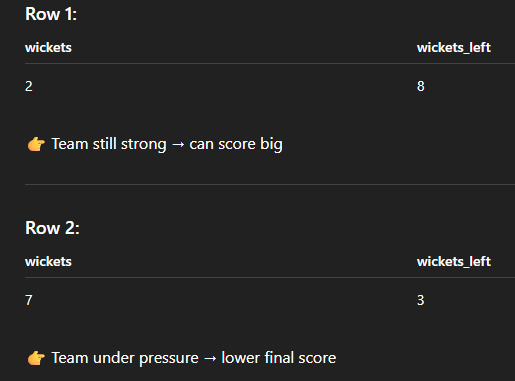

In [83]:
df.head()

,batting_team,bowling_team,runs,wickets,overs,runs_last_5,wickets_last_5,total,run_rate,wickets_left
32,Kolkata Knight Riders,Royal Challengers Bangalore,61,0,5.1,59,0,222,11.960784,10
33,Kolkata Knight Riders,Royal Challengers Bangalore,61,1,5.2,59,1,222,11.730769,9
34,Kolkata Knight Riders,Royal Challengers Bangalore,61,1,5.3,59,1,222,11.509434,9
35,Kolkata Knight Riders,Royal Challengers Bangalore,61,1,5.4,59,1,222,11.296296,9
36,Kolkata Knight Riders,Royal Challengers Bangalore,61,1,5.5,58,1,222,11.090909,9


In [84]:
X = df.drop('total', axis=1)
y = df['total']

In [85]:
categorical_cols = ['batting_team', 'bowling_team']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ],
    remainder='passthrough'
)

In [86]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [87]:
model_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

In [88]:
model_pipeline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['batting_team',
                                                   'bowling_team'])])),
                ('model', RandomForestRegressor(random_state=42))])

In [89]:
pred = model_pipeline.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))

MAE: 3.9791559253718938
RMSE: 7.385971661620005


In [90]:
models = {}
train_score_forest = model_pipeline.score(X_train, y_train)*100
test_score_forest = model_pipeline.score(X_test, y_test)*100

print(f'Train Score : {train_score_forest:.2f}%\nTest Score : {test_score_forest:.2f}%')

models["forest"] = test_score_forest

Train Score : 99.07%
Test Score : 93.90%


In [91]:
sample = pd.DataFrame({
    'batting_team': ['Mumbai Indians'],
    'bowling_team': ['Chennai Super Kings'],
    'runs': [100],
    'wickets': [2],
    'overs': [10],
    'runs_last_5': [50],
    'wickets_last_5': [1],
    'run_rate': [100/10],
    'wickets_left': [10-2]
})

In [92]:
prediction = model_pipeline.predict(sample)
print("Predicted Score:", int(prediction[0]))


Predicted Score: 190


In [93]:
df['predicted_score'] = model_pipeline.predict(X)

/tmp/ipykernel_4793/2755865080.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['predicted_score'] = model_pipeline.predict(X)


In [94]:
df['error'] = df['total'] - df['predicted_score']

/tmp/ipykernel_4793/3162603072.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['error'] = df['total'] - df['predicted_score']


In [95]:
df.to_csv('ipl_predictions.csv', index=False)

In [96]:
df.head()

,batting_team,bowling_team,runs,wickets,overs,runs_last_5,wickets_last_5,total,run_rate,wickets_left,predicted_score,error
32,Kolkata Knight Riders,Royal Challengers Bangalore,61,0,5.1,59,0,222,11.960784,10,216.57,5.43
33,Kolkata Knight Riders,Royal Challengers Bangalore,61,1,5.2,59,1,222,11.730769,9,215.13,6.87
34,Kolkata Knight Riders,Royal Challengers Bangalore,61,1,5.3,59,1,222,11.509434,9,217.24,4.76
35,Kolkata Knight Riders,Royal Challengers Bangalore,61,1,5.4,59,1,222,11.296296,9,217.24,4.76
36,Kolkata Knight Riders,Royal Challengers Bangalore,61,1,5.5,58,1,222,11.090909,9,197.46,24.54


In [97]:
def predict_score_pipeline(batting_team, bowling_team, overs, runs, wickets, runs_last_5, wickets_last_5):
    current_run_rate = runs / overs
    wickets_left = 10 - wickets

    input_data = pd.DataFrame({
        'batting_team': [batting_team],
        'bowling_team': [bowling_team],
        'runs': [runs],
        'wickets': [wickets],
        'overs': [overs],
        'runs_last_5': [runs_last_5],
        'wickets_last_5': [wickets_last_5],
        'run_rate': [current_run_rate],
        'wickets_left': [wickets_left]
    })

    prediction = model_pipeline.predict(input_data)
    return int(round(prediction[0]))

In [98]:
batting_team='Kings XI Punjab'
bowling_team='Chennai Super Kings'
score = predict_score_pipeline(batting_team, bowling_team, overs=18.0, runs=129, wickets=6, runs_last_5=34, wickets_last_5=2)
print(f'Predicted Score : {score} || Actual Score : 153')

Predicted Score : 141 || Actual Score : 153


In [99]:
batting_team='Delhi Daredevils'
bowling_team='Mumbai Indians'
score = predict_score_pipeline(batting_team, bowling_team, overs=18.0, runs=96, wickets=8, runs_last_5=18, wickets_last_5=4)
print(f'Predicted Score : {score} || Actual Score : 110')

Predicted Score : 97 || Actual Score : 110


In [100]:
# Live Test
batting_team="Kolkata Knight Riders"
bowling_team="Chennai Super Kings"
score = predict_score_pipeline(batting_team, bowling_team, overs=18.0, runs=150, wickets=4, runs_last_5=57, wickets_last_5=1)
print(f'Predicted Score : {score} || Actual Score : 172')

Predicted Score : 169 || Actual Score : 172


In [102]:
# Live Test
batting_team="Kings XI Punjab"
bowling_team="Rajasthan Royals"
score = predict_score_pipeline(batting_team, bowling_team, overs=14.0, runs=118, wickets=1, runs_last_5=45, wickets_last_5=0)
print(f'Predicted Score : {score} || Actual Score : 185')

Predicted Score : 176 || Actual Score : 185
